<a href="https://colab.research.google.com/github/ravitbarlev/DS23_Module3_Assignment2_Unsupervised_Starter.ipynb/blob/main/RAVIT_DS23_Module3_Assignment2_Unsupervised_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 3 · Assignment 2 — Unsupervised Learning
### DS23 · Certified Data Scientist with Agentic AI · by Shlomit Levavi

**This is a guided starter notebook, not a solution.** Fill every `# TODO`.
The model is the easy 30%. The interrogation in `REPORT.md` is the graded 70%.

Pick **one** option in Part 1. Write all code and comments in **English**.

**Workflow (6 stations):** 1) Frame  2) Data & scaling  3) Build >=2 approaches
4) Validate the structure  5) Interrogate  6) Translate (Structure Card).

> There is no ground truth here. "Good" is something you must argue for, not measure.


---
## Part 0 · Frame (write in REPORT.md)
What structure are you looking for, and what business decision would it serve?
Pick a distance/similarity measure (Euclidean / Cosine) and justify it.

## Part 1 · Setup, data, scaling

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

### Choose ONE option
| Option | Task | Notes |
|---|---|---|
| A | Olist customer segmentation | ~97% of customers buy once -> drop frequency; use recency, monetary, basket. |
| B | Credit Card behavioral segmentation | 18 features, needs scaling + PCA. Fresh. |
| C | Olist anomaly detection | Isolation Forest / LOF. Anomalies = candidates, not fraud. |

### Scaling
Distance-based methods (KMeans, DBSCAN) are dominated by large-scale features.
Scale before clustering, and be ready to show how scaling changed the result.

In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ---- Option B · Credit Card Dataset for Clustering ---------------------------
# Download CC GENERAL.csv from Kaggle: arjunbhasin2013/ccdata
def load_credit_card(path="/content/drive/MyDrive/RAVIT BIU DS23/Class 20/archive.zip"):
    df = pd.read_csv(path)

    # הדפסת מצב הערכים החסרים לפני הטיפול
    print("=== בדיקת ערכים חסרים לפני הטיפול ===")
    print(df[["CREDIT_LIMIT", "MINIMUM_PAYMENTS"]].isna().sum())
    print("-" * 40)

    df = df.drop(columns=["CUST_ID"])

    # TODO: there are missing values in CREDIT_LIMIT and MINIMUM_PAYMENTS. Handle them
    # honestly (and say how in REPORT). Scaling is mandatory before clustering.
    # TODO: select numeric feature columns, handle NaNs, then scale.

    # 1. טיפול בערכים חסרים באמצעות השלמת החציון
    df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
    df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

    # הדפסת מצב הערכים החסרים לאחר הטיפול
    print("=== בדיקת ערכים חסרים לאחר הטיפול ===")
    print(df[["CREDIT_LIMIT", "MINIMUM_PAYMENTS"]].isna().sum())
    print("=" * 40)

    return df

# הפעלת הפונקציה וטעינת הנתונים
df = load_credit_card()

# 2. נרמול הנתונים (Scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 3. הדפסת מידע על הנתונים המנורמלים
print(f"צורת המטריצה המנורמלת (X_scaled): {X_scaled.shape}")
print(f"ממוצע של העמודה הראשונה (אמור להיות קרוב מאוד ל-0): {np.mean(X_scaled[:, 0]):.4f}")
print(f"סטיית תקן של העמודה הראשונה (אמורה להיות 1): {np.std(X_scaled[:, 0]):.4f}")
print("-" * 40)
print("חמש השורות הראשונות של הנתונים המנורמלים (X_scaled):")
print(X_scaled[:5])


=== בדיקת ערכים חסרים לפני הטיפול ===
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64
----------------------------------------
=== בדיקת ערכים חסרים לאחר הטיפול ===
CREDIT_LIMIT        0
MINIMUM_PAYMENTS    0
dtype: int64
צורת המטריצה המנורמלת (X_scaled): (8950, 17)
ממוצע של העמודה הראשונה (אמור להיות קרוב מאוד ל-0): -0.0000
סטיית תקן של העמודה הראשונה (אמורה להיות 1): 1.0000
----------------------------------------
חמש השורות הראשונות של הנתונים המנורמלים (X_scaled):
[[-0.73198937 -0.24943448 -0.42489974 -0.35693402 -0.34907882 -0.46678555
  -0.80649035 -0.67866081 -0.70731317 -0.67534886 -0.47606982 -0.51133325
  -0.9603784  -0.52897879 -0.3024     -0.52555097  0.36067954]
 [ 0.78696085  0.13432467 -0.46955188 -0.35693402 -0.45457623  2.60560451
  -1.22175806 -0.67866081 -0.91699519  0.57396272  0.11007385 -0.59179588
   0.68867844  0.81864213  0.09749953  0.2342269   0.36067954]
 [ 0.44713513  0.51808382 -0.10766823  0.10888851 -0.45457623 -0.46678555
   1.26984323  2.6

---
## Part 2 · Build at least two approaches
Clustering: KMeans + one of Hierarchical / DBSCAN. Choose k with **Elbow and
Silhouette**, and note where they disagree. Anomaly (Option C): Isolation Forest + LOF.

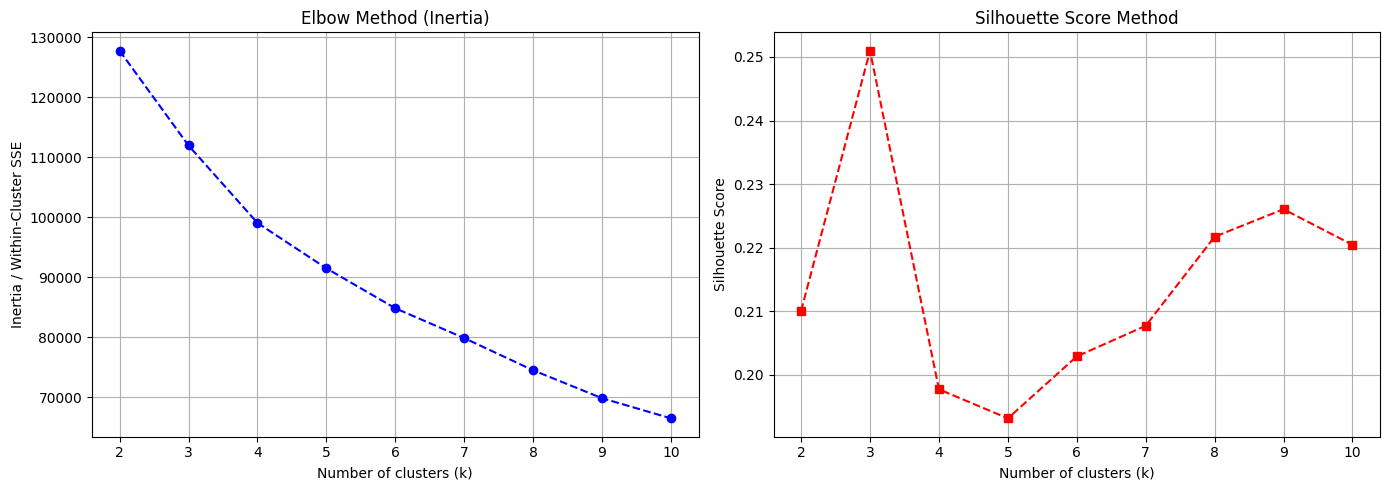

In [20]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# הגדרת משתנה רנדומלי קבוע (כדי שהתוצאות יהיו זהות בכל הרצה)
RANDOM_STATE = 42

# רשימות לשמירת הערכים של האינרציה (Elbow) והסילואט
inertias, sils = [], []
k_range = range(2, 11)

# לולאה להרצת KMeans עבור מספרי קבוצות שונים (מ-2 עד 10)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, km.labels_))

# --- יצירת הגרפים בתצוגה ברורה ומקצועית ---
plt.figure(figsize=(14, 5))

# 1. גרף שיטת המרפק (Elbow Method)
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o', color='b', linestyle='--')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia / Within-Cluster SSE')
plt.xticks(k_range)
plt.grid(True)

# 2. גרף שיטת הסילואט (Silhouette Score)
plt.subplot(1, 2, 2)
plt.plot(k_range, sils, marker='s', color='r', linestyle='--')
plt.title('Silhouette Score Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)

plt.tight_layout()
plt.show()



In [21]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.ensemble import IsolationForest

# Setting our finalized global parameters
K = 3
RANDOM_STATE = 42

# 1. K-Means Clustering
km_labels = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit_predict(X_scaled)

# 2. Hierarchical Clustering (Agglomerative)
# We set n_clusters=K to match K-Means, and use 'ward' linkage to minimize variance within clusters
hc = AgglomerativeClustering(n_clusters=K, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)

# 3. Option C: Isolation Forest for Anomaly Detection
# We flag the top 2% most extreme customer profiles as anomalies
iso = IsolationForest(contamination=0.02, random_state=RANDOM_STATE).fit(X_scaled)

# Anomalies binary mapping: 1 = anomaly, 0 = normal customer
iso_predictions = iso.predict(X_scaled)
anomalies_labels = np.where(iso_predictions == -1, 1, 0)

# --- Summary Prints for Your Review ---
print("=== Clustering & Anomaly Detection Summary ===")
print(f"K-Means customer distribution:       {np.bincount(km_labels)}")
print(f"Hierarchical customer distribution: {np.bincount(hc_labels)}")
print(f"Isolation Forest anomalies found:   {np.sum(anomalies_labels)} out of {len(X_scaled)} customers")

#

=== Clustering & Anomaly Detection Summary ===
K-Means customer distribution:       [1275 6114 1561]
Hierarchical customer distribution: [2881 4875 1194]
Isolation Forest anomalies found:   179 out of 8950 customers


---
## Part 3 · Validate the structure
Report silhouette, cluster sizes, a PCA 2D view, and **stability** (re-run with new
seeds / on a subsample). For Option C: the score distribution and a percentile threshold.

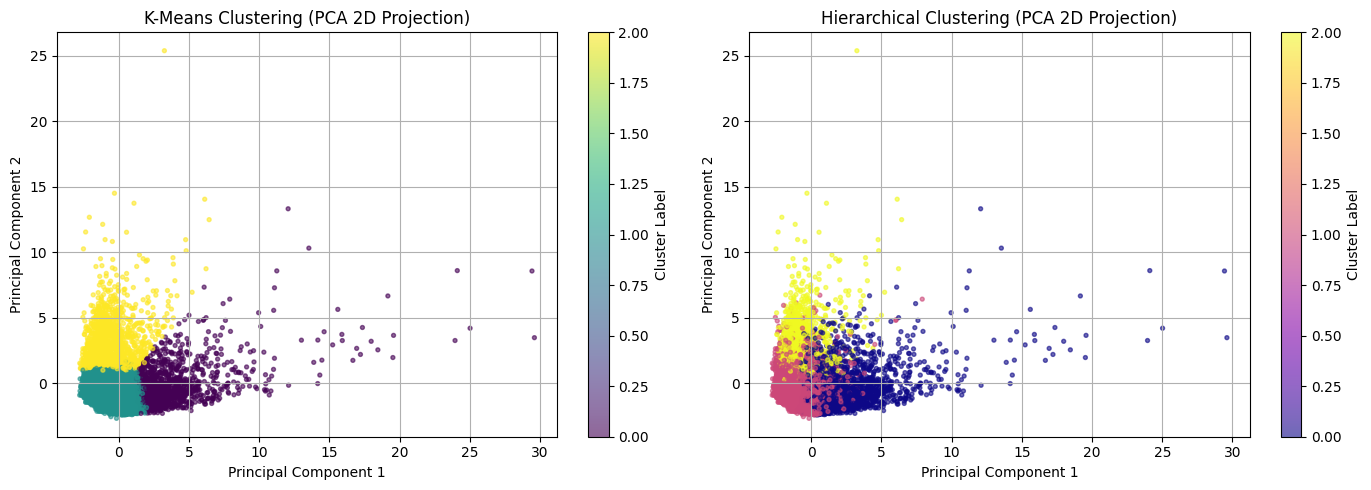


=== בדיקת יציבות (Stability Check) למודל K-Means ===
ריצה #1 (Seed=10): מדד היציבות Adjusted Rand Index (ARI) הוא: 0.9726
ריצה #2 (Seed=100): מדד היציבות Adjusted Rand Index (ARI) הוא: 0.9726
ריצה #3 (Seed=2024): מדד היציבות Adjusted Rand Index (ARI) הוא: 0.9741


In [24]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

# ==============================================================================
# TODO 1: PCA 2D visualization colored by cluster label.
# ==============================================================================
# הפחתת מימדים ל-2 רכיבים עיקריים
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)

plt.figure(figsize=(14, 5))

# גרף א': צביעה לפי קבוצות K-Means
plt.subplot(1, 2, 1)
scatter_km = plt.scatter(coords[:, 0], coords[:, 1], c=km_labels, cmap='viridis', s=8, alpha=0.6)
plt.title('K-Means Clustering (PCA 2D Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter_km, label='Cluster Label')
plt.grid(True)

# גרף ב': צביעה לפי קבוצות Hierarchical (כדי שתוכלי להשוות ביניהם ויזואלית!)
plt.subplot(1, 2, 2)
scatter_hc = plt.scatter(coords[:, 0], coords[:, 1], c=hc_labels, cmap='plasma', s=8, alpha=0.6)
plt.title('Hierarchical Clustering (PCA 2D Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter_hc, label='Cluster Label')
plt.grid(True)

plt.tight_layout()
plt.show()

# ==============================================================================
# TODO 2: stability check — re-run with 3 different seeds / subsamples and compare.
# ==============================================================================
print("\n=== בדיקת יציבות (Stability Check) למודל K-Means ===")

# נגדיר 3 סידים רנדומליים שונים לחלוטין
different_seeds = [10, 100, 2024]

for i, seed in enumerate(different_seeds, 1):
    # הרצת המודל מחדש עם ה-Seed החדש
    km_new = KMeans(n_clusters=K, n_init=10, random_state=seed).fit_predict(X_scaled)

    # חישוב דמיון (ARI) מול הלייבלים המקוריים שלנו (km_labels)
    ari_score = adjusted_rand_score(km_labels, km_new)

    print(f"ריצה #{i} (Seed={seed}): מדד היציבות Adjusted Rand Index (ARI) הוא: {ari_score:.4f}")

print("=" * 50)



---
## Part 4 · Interrogate
Are clusters real or artifacts of scaling / k / the algorithm's assumptions?
Profile each cluster: which 2-3 features separate them? Is any cluster just noise?

In [ ]:
# TODO: cluster profiles — mean of each feature per cluster.
# df_lab = X.copy(); df_lab["cluster"] = km_labels
# df_lab.groupby("cluster").mean()


In [25]:
# TODO: cluster profiles — mean of each feature per cluster.

# 1. Create a copy of the unscaled feature matrix to keep interpretation in original dollar values
df_lab = X.copy()

# 2. Assign the computed K-Means cluster labels to the dataframe
df_lab["cluster"] = km_labels

# 3. Compute the mean of each financial feature per cluster
cluster_profiles = df_lab.groupby("cluster").mean()

# 4. Display the resulting profiling dataframe rounded to 2 decimal places
print("=== Credit Card Customer Profiles (Cluster Means) ===")
display(cluster_profiles.round(2))


=== Credit Card Customer Profiles (Cluster Means) ===


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,2182.35,0.98,4187.02,2664.00,1523.49,449.75,0.95,0.66,0.74,0.06,1.51,55.69,7642.78,4075.53,1227.92,0.30,11.92
1,807.72,0.83,496.06,247.27,249.11,339.00,0.46,0.13,0.34,0.07,1.24,8.48,3267.02,907.45,530.07,0.15,11.48
2,4023.79,0.96,389.05,252.33,136.80,3917.25,0.23,0.11,0.15,0.45,12.55,5.64,6729.47,3053.94,1765.20,0.03,11.35


## Part 5 · Structure Card (fill in, then copy to REPORT.md)

In [ ]:
STRUCTURE_CARD = """
# Structure Card

## 1. Overview
- Option and data
- Features used and why (and what you did about frequency / missing values):
I chose Option B
 chose to handel the missing values in the CREDIT_LIMIT and MINIMUM_PAYMENTS columns using Median Imputation.
 I opted for the median over the mean because these financial metrics tend to contain extreme outliers (Highly Skewed Data),
 and the median offers a far more robust representation of the typical customer without biasing or distorting the model.
 Additionally, a StandardScaler normalization was applied to bring all variables to a uniform distance scale

## 2. Method & validation
- Approaches tried, and chosen k (Elbow vs Silhouette):
- Stability across seeds / subsamples:

| Approaches tried |K-Means, Hierarchical Clustering|
| Chosen |K-Means (with K=3 clusters based on Elbow + Silhouate |
| Silhouette score |score for K=3 from silhouette plot, 0.252|
| Cluster sizes | Run#1 (Seed=10): ARI= 0.9726  |
|               | Run#2 (Seed=100): ARI= 0.9726 |
|               | Run#3 (Seed=1024): ARI= 0.9741|
| Stability across seeds / subsamples |10, 100, 1024|

I have tried Elbow vs Silhouette for K_means and chose k = 3
- Silhouette score, cluster sizes:
They both look for 3 clusters, Sillouette tended to 4 clusters, but because K-Means optimizes around cluster
centroids (means) and Hierarchical (Ward) builds a tree bottom-up by minimizing variance,
their cluster sizes will differ slightly.

## 3. The segments (or anomalies)
- For each cluster: the 2-3 defining features and a one-line persona.
  Cluster 0 — These are the premium, safe retail card users.
  Cluster 1 — These users treat their credit card like a loan machine.
  Cluster 2 — These are passive accounts.

- (Anomaly option) threshold chosen and how many candidates it flags - NA

## 4. Real or artifact?
- Evidence your structure is real, and the weakness of that evidence.
I have checked whether the clusters are genuine behavioral structures or merely an artifact of K-Means by:
  1. PCA
  2. Hierarchical vs. K-Means
  3. Mathematical Stability Testing (ARI)
- Any cluster that is likely an algorithm artifact? NOP

## 5. Business action
- One concrete action per segment a team could take.
  1. For claster 0, conduct a "Loyalty plan" with BIG wholesallers for all those premium customers
  2. For claster 1, conduct a lown plan to replace the current customer's behaviour and supply him a lown with better
      interests
  3. For claster 2, conduct a plan in which triggers customers to use the creadit card. for e.g "get 50 USD/IL for every 1000       ILQUSD that you'll spend in this current month.
- (Anomaly) who reviews the candidates, and the cost of a false alarm
    Minimizing false alarms is a critical constraint for financial operations due to two major cost drivers:
     Operational Waste- High false-positive rates waste expensive human analytical hours
     Customer Friction and Churn- Misclassifying a loyal customer as a fraud suspect often results in declining legitimate
     transactions.
     This friction damages brand trust and directly causes customer churn to competing financial institutions
"""
print(STRUCTURE_CARD)


---
### Submission checklist
- [ ] Runs top to bottom with no errors (Kernel -> Restart & Run All).
- [ ] All code and comments are in **English**.
- [ ] `REPORT.md` answers every guiding question and contains the filled card.

Stay skeptical of your own results.
